In [4]:
# Code for Parameter Analysis (Section 2.1.2)

import numpy as np
import matplotlib.pyplot as plt

A = lambda theta, q: -(1 - 2 * theta + theta ** 2 * (1 - q ** 2))
B = lambda theta, q: 2 - (2 - q ** 2) * theta
C = lambda theta, q: - (1 - theta * (1 - q ** 2)) * (1 - theta)
tau_bar_quad = lambda theta, q: (- B(theta, q) + np.sqrt(B(theta, q) ** 2 - 4 * A(theta, q) * C(theta, q))) / (2 * A(theta, q))
tau_bar_lin = lambda theta, q: - C(theta, q) / B(theta, q)
def tau_bar(theta, q):
    if A(theta, q) != 0 and B(theta, q) != 0:
        return tau_bar_quad(theta, q)
    elif B(theta, q) != 0:
        return tau_bar_lin(theta, q)
    else:
        return 0

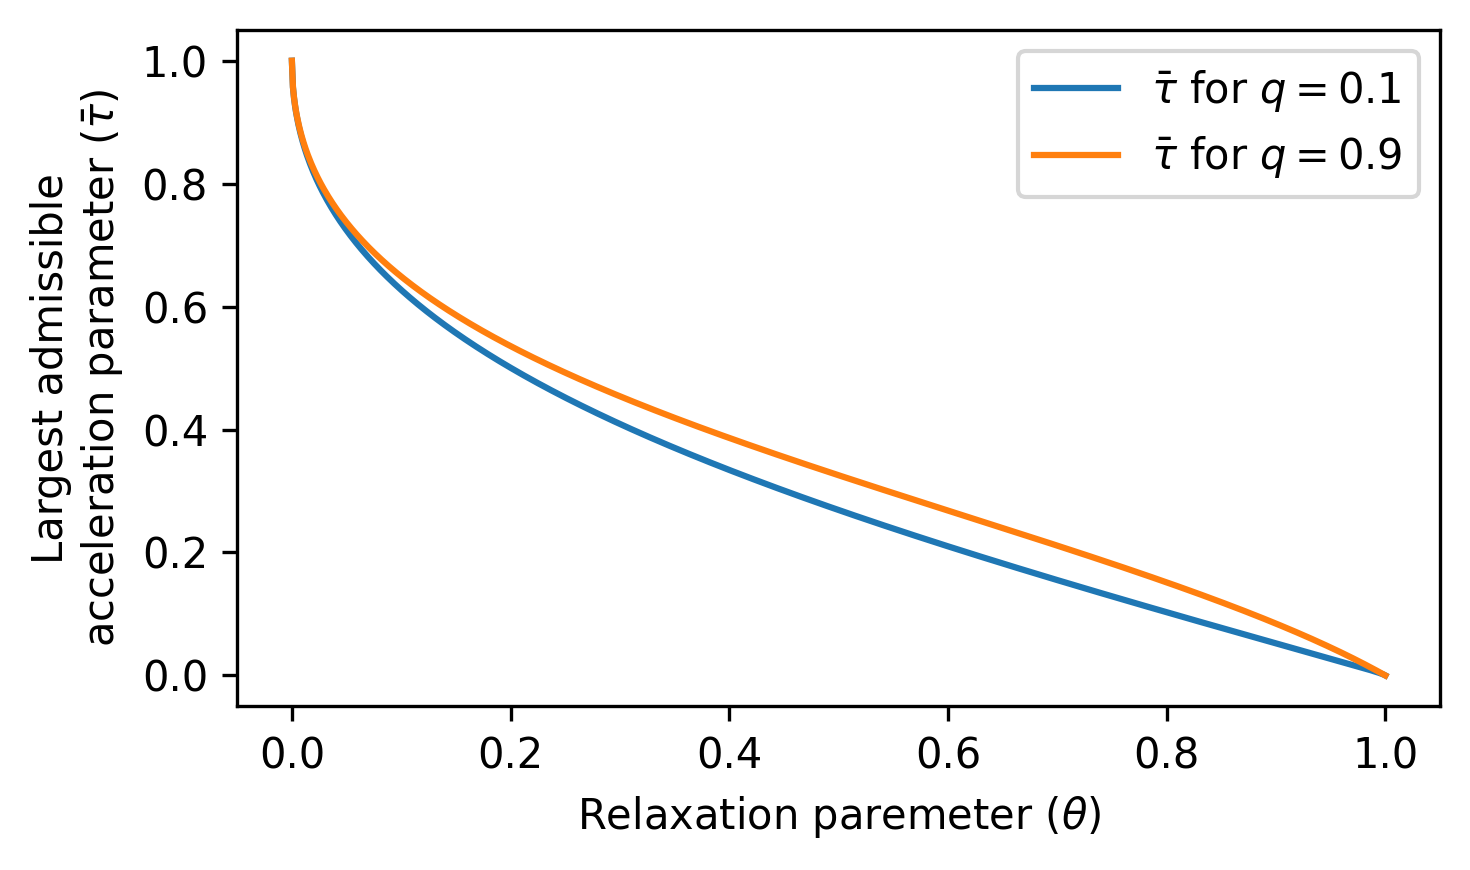

In [5]:
thetas = np.linspace(0, 1, 1024)

fig = plt.figure(figsize=(5, 3), dpi=300)
plt.plot(thetas, [tau_bar(theta, 0.1) for theta in thetas], label=r"$\bar\tau$ for $q=0.1$")
plt.plot(thetas, [tau_bar(theta, 0.9) for theta in thetas], label=r"$\bar\tau$ for $q=0.9$")
plt.xlabel(r"Relaxation paremeter ($\theta$)")
plt.ylabel(r"Largest admissible" "\n" r"acceleration parameter ($\bar\tau$)")
plt.legend()
plt.tight_layout()
plt.show()

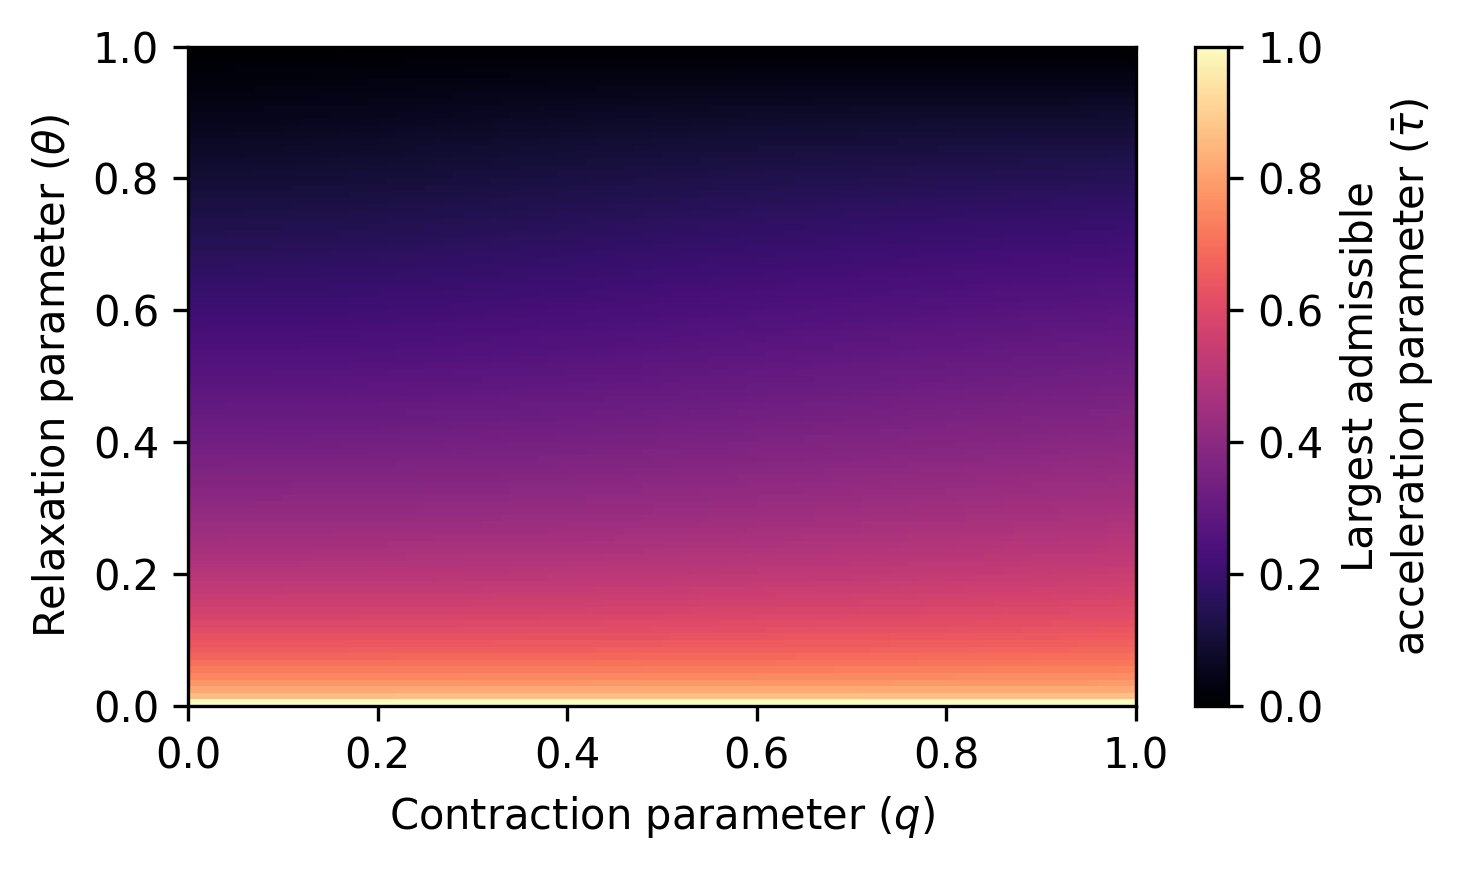

In [6]:
theta_range = np.linspace(0, 1, 100)
q_range = np.linspace(0, 1, 100)
Q, THETA = np.meshgrid(q_range, theta_range)
Z = [[tau_bar(theta, q) for q in q_range] for theta in theta_range]

plt.figure(figsize=(5, 3), dpi=300)
plt.imshow(Z, extent=[q_range[0], q_range[-1], theta_range[0], theta_range[-1]], origin='lower', cmap='magma', aspect='auto')
cbar = plt.colorbar()
cbar.set_label(r"Largest admissible" "\n" r"acceleration parameter ($\bar\tau$)")
plt.xlabel(r"Contraction parameter ($q$)")
plt.ylabel(r"Relaxation parameter ($\theta$)")
plt.tight_layout()
plt.show()